Found 545 valid designs fitting < 130mm track.


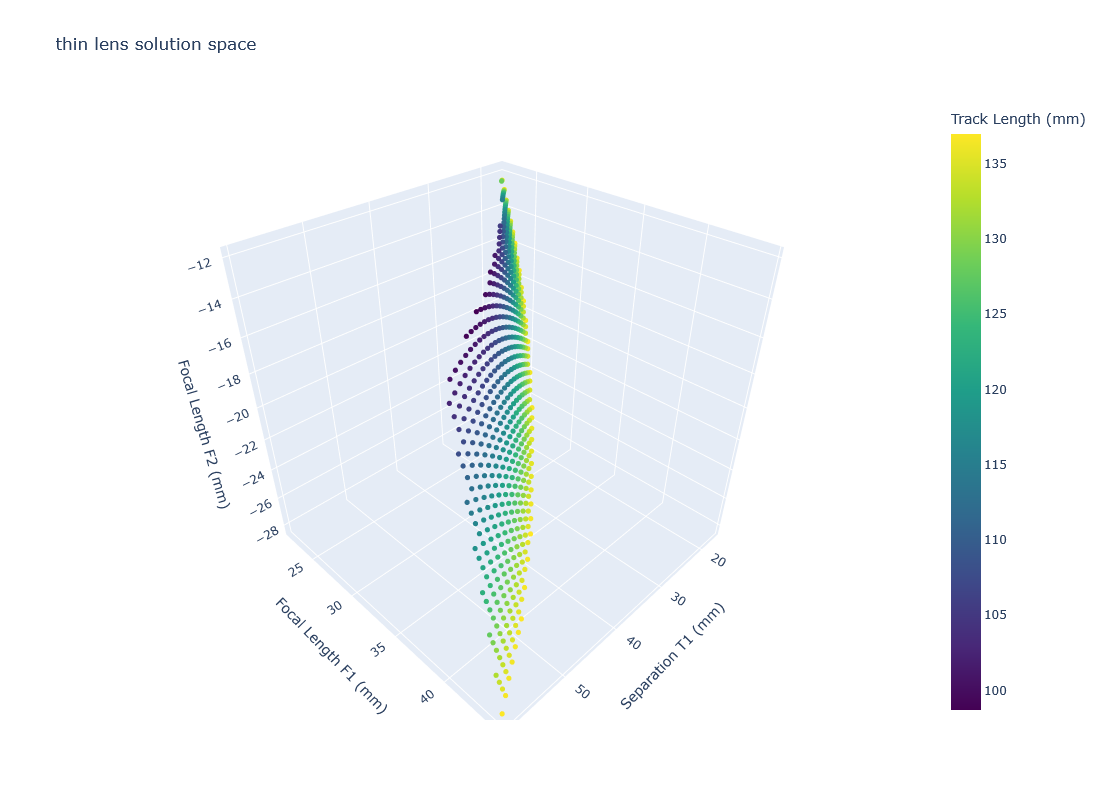

In [17]:
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt


t1_range = np.arange(1, 60, 0.5)    
f1_range = np.arange(1, 100, 0.5)  
p1_range = 1 / f1_range

T1, P1 = np.meshgrid(t1_range, p1_range)

P2_num = (1.333333 - 100 * P1)
P2_den = (100 + T1 * (1 - 100 * P1))

# Handle potential division by zero
with np.errstate(divide='ignore', invalid='ignore'):
    P2 = np.where(P2_den != 0, P2_num / P2_den, np.nan)

F1 = 1 / P1
F2 = 1 / P2

Y2 = 100 + T1 * (1 - 100 * P1)
T2 = 3 * Y2

Lens_Track = T1 + T2

mask = (
    (T2 > 5) &
    (Lens_Track < 137) &        
    (np.abs(F2) > 12) &
    np.isfinite(P2) &
    (P2 != 0)
)

# Stack valid results: [T1, F1, F2, T2, Track]
points = np.column_stack((T1[mask], 
                          F1[mask], 
                          F2[mask], 
                          T2[mask], 
                          Lens_Track[mask]))

# --- 5. Plotting ---
print(f"Found {len(points)} valid designs fitting < 130mm track.")

fig = go.Figure(data=go.Scatter3d(
    x=points[:, 0],     # T1
    y=points[:, 1],     # F1
    z=points[:, 2],     # F2
    mode='markers',
    marker=dict(
        size=3,
        color=points[:, 4], # Color by Track Length
        colorscale='Viridis',
        colorbar=dict(title="Track Length (mm)"),
        showscale=True
    )
))

fig.update_layout(
    width=800, height=800,
    title="thin lens solution space",
    scene=dict(
        xaxis_title='Separation T1 (mm)',
        yaxis_title='Focal Length F1 (mm)',
        zaxis_title='Focal Length F2 (mm)',
        aspectmode='cube'
    )
)

fig.show()


In [12]:

# --- 6. Helper Function to Print Prescription ---
def print_prescription(point_index):
    """Prints the Zemax starting values for a specific point in the filtered list."""
    if point_index >= len(points):
        print("Index out of range.")
        return

    # Unpack values
    t1, f1, f2, bfl, track = points[point_index]
    
    # Radii Calculation (Standard Achromat approximation: R1 ~ 0.6*F)
    # Doublet 1 (Positive)
    r1_1 = 0.6 * f1
    r1_2 = -0.35 * f1
    r1_3 = -1.4 * f1
    
    # Doublet 2 (Negative usually) - Crown First
    r2_1 = 0.6 * f2
    r2_2 = -0.35 * f2
    r2_3 = -1.4 * f2

    print(f"\n>>> PRESCRIPTION FOR INDEX {point_index} <<<")
    print(f"Stats: F1={f1:.2f}, F2={f2:.2f}, Sep={t1:.2f}, BFL={bfl:.2f}, Track={track:.2f}")
    print("-" * 60)
    print(f"{'Surf':<5} {'Radius':<10} {'Thick':<10} {'Glass':<10} {'Semi-Dia'}")
    print("-" * 60)
    print(f"{'OBJ':<5} {'Infinity':<10} {'100.0':<10} {'':<10} {'5.0'}")
    # Doublet 1
    print(f"{'1':<5} {r1_1:<10.2f} {'4.0':<10} {'N-BK7':<10} {'8.0'}")
    print(f"{'2':<5} {r1_2:<10.2f} {'2.0':<10} {'N-SF5':<10} {'8.0'}")
    print(f"{'3':<5} {r1_3:<10.2f} {t1/2:<10.2f} {'':<10} {'8.0'}")
    # Stop
    print(f"{'STOP':<5} {'Infinity':<10} {t1/2:<10.2f} {'':<10} {'Auto'}")
    # Doublet 2
    print(f"{'5':<5} {r2_1:<10.2f} {'2.0':<10} {'N-BK7':<10} {'6.0'}")
    print(f"{'6':<5} {r2_2:<10.2f} {'2.0':<10} {'N-SF5':<10} {'6.0'}")
    print(f"{'7':<5} {r2_3:<10.2f} {bfl:<10.2f} {'':<10} {'6.0'}")
    print(f"{'IMA':<5} {'Infinity':<10} {'-':<10} {'':<10} {'15.0'}")
    print("-" * 60)

In [14]:
def calculate_min_diameters(point):
    """
    Calculates the minimum 'Clear Aperture' diameter for the lenses
    based on f/10 and the 10x10mm field size.
    """
    t1, f1, f2, bfl, track = point
    
    # --- 1. Marginal Ray Trace (Defines Aperture Size) ---
    # Working F/# = 10 -> NA_img = 0.05 -> u_img = -0.05
    # Magnification = 3 -> u_obj = 3 * 0.05 = 0.15
    u_m0 = 0.15
    y_m1 = 100.0 * u_m0             # Height at Lens 1
    
    # Refraction at Lens 1
    phi1 = 1/f1
    u_m1 = u_m0 - y_m1 * phi1
    
    # Transfer to Stop (at t1/2)
    y_m_stop = y_m1 + (t1/2) * u_m1
    
    # Transfer to Lens 2 (at t1/2 from stop)
    y_m2 = y_m_stop + (t1/2) * u_m1 # Angle u_m1 hasn't changed (air space)
    
    # --- 2. Chief Ray Trace (Defines Field Size) ---
    # We must find the starting angle u_c0 such that y_c_stop = 0.
    # Object Height h = 7.1mm (Diagonal of 10x10)
    h = 7.1
    
    # Symbolic solve:
    # y_c1 = h + 100 * u_c0
    # u_c1 = u_c0 - y_c1 * phi1
    # y_c_stop = y_c1 + (t1/2) * u_c1 = 0
    # Substitute and solve for u_c0:
    # (h + 100u) + d * (u - (h + 100u)phi1) = 0
    # h + 100u + du - dh(phi1) - 100u(d)(phi1) = 0
    # u * [100 + d - 100*d*phi1] = -h + h*d*phi1
    
    d = t1 / 2.0
    term_bracket = 100 + d - (100 * d * phi1)
    
    if term_bracket == 0:
        u_c0 = 0 # Safety catch, though unlikely
    else:
        u_c0 = (-h + h * d * phi1) / term_bracket
        
    # Now trace the Chief Ray with known u_c0
    y_c1 = h + 100 * u_c0
    u_c1 = u_c0 - y_c1 * phi1
    y_c2 = 0 + d * u_c1   # From stop (height 0) to Lens 2
    
    # --- 3. Calculate Diameters ---
    # Diameter = 2 * (|Marginal| + |Chief|)
    # We add 2mm 'Mechanical Margin' for safety
    dia1 = 2 * (abs(y_m1) + abs(y_c1))
    dia2 = 2 * (abs(y_m2) + abs(y_c2))
    
    print(f"--- Estimated Lens Diameters (Clear Aperture) ---")
    print(f"Lens 1 Diameter: {dia1:.2f} mm (Min Clear Ap: {dia1-2:.2f} mm)")
    print(f"Lens 2 Diameter: {dia2:.2f} mm (Min Clear Ap: {dia2-2:.2f} mm)")
    
    # Return them if you want to use them in logic
    return dia1, dia2

In [15]:
# ... inside your usage block ...
print_prescription(50)         # Prints the radii
calculate_min_diameters(points[50]) # Prints the diameters


>>> PRESCRIPTION FOR INDEX 50 <<<
Stats: F1=27.50, F2=-12.51, Sep=27.00, BFL=86.45, Track=113.45
------------------------------------------------------------
Surf  Radius     Thick      Glass      Semi-Dia
------------------------------------------------------------
OBJ   Infinity   100.0                 5.0
1     16.50      4.0        N-BK7      8.0
2     -9.62      2.0        N-SF5      8.0
3     -38.50     13.50                 8.0
STOP  Infinity   13.50                 Auto
5     -7.51      2.0        N-BK7      6.0
6     4.38       2.0        N-SF5      6.0
7     17.52      86.45                 6.0
IMA   Infinity   -                     15.0
------------------------------------------------------------
--- Estimated Lens Diameters (Clear Aperture) ---
Lens 1 Diameter: 32.98 mm (Min Clear Ap: 30.98 mm)
Lens 2 Diameter: 11.62 mm (Min Clear Ap: 9.62 mm)


(np.float64(32.97628793225123), np.float64(11.621742477705784))

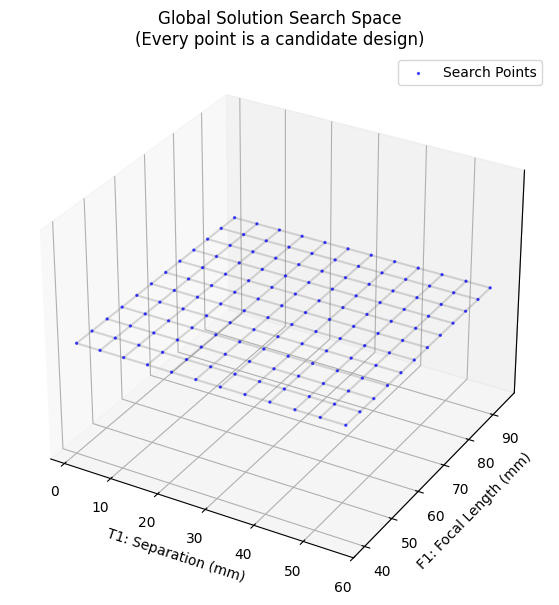

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Mesh (Input Space)
# Note: For plotting, a coarser step (e.g., 2.0) looks better than 0.5
t1_range = np.arange(1, 60, 5)   
f1_range = np.arange(40, 100, 5)  
p1_range = 1 / f1_range

T1, P1 = np.meshgrid(t1_range, f1_range)
Z = np.zeros_like(T1) # We plot this at Z=0 to show the "Input Plane"

# 2. Setup the 3D Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 3. Plot the "Grid" (Wireframe)
# rstride/cstride controls how many lines are drawn (row/column step)
ax.plot_wireframe(T1, P1, Z, color='gray', alpha=0.3, rstride=1, cstride=1)

# 4. Plot the "Points" (Scatter)
# This emphasizes that the calculation is discrete (point-by-point)
ax.scatter(T1, P1, Z, c='blue', s=2, alpha=0.6, label='Search Points')

# 5. Labels and Formatting
ax.set_xlabel('T1: Separation (mm)')
ax.set_ylabel('F1: Focal Length (mm)')
ax.set_zlabel('Constraint Check')
ax.set_title('Global Solution Search Space\n(Every point is a candidate design)')

# Hide Z-axis ticks since they are meaningless for the input mesh
ax.set_zticks([])
ax.view_init(elev=30, azim=-60) # Adjust camera angle

plt.legend()
plt.savefig('MeshPoints.png', dpi=300)
plt.show()

Found 545 valid designs.


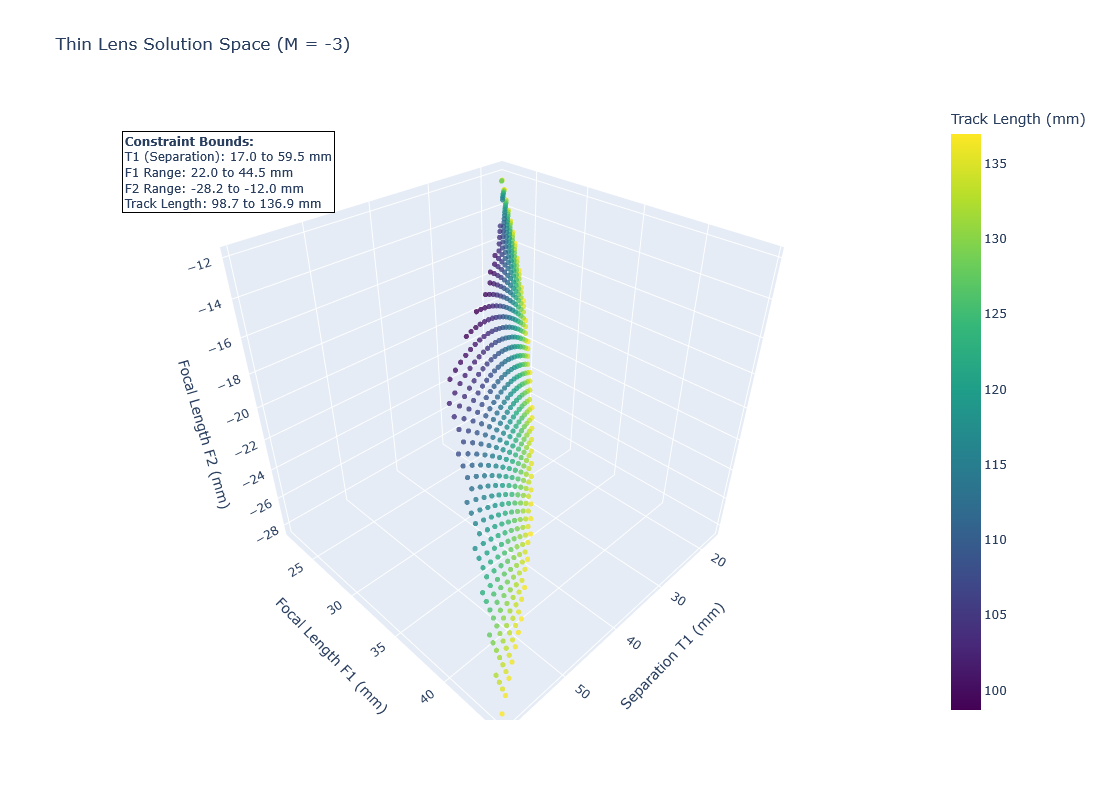

In [27]:
import numpy as np
import plotly.graph_objects as go

# --- 1. Define Search Space ---
t1_range = np.arange(1, 60, 0.5)     
f1_range = np.arange(1, 100, 0.5)   
p1_range = 1 / f1_range

T1, P1 = np.meshgrid(t1_range, p1_range)

# --- 2. Paraxial Solve (Vectorized) ---
# P2 = (u1 - u2) / y2 logic
P2_num = (1.333333 - 100 * P1)
P2_den = (100 + T1 * (1 - 100 * P1))

with np.errstate(divide='ignore', invalid='ignore'):
    P2 = np.where(P2_den != 0, P2_num / P2_den, np.nan)

# --- 3. Physical Properties ---
F1 = 1 / P1
F2 = 1 / P2
Y2 = 100 + T1 * (1 - 100 * P1)
T2 = 3 * Y2
Lens_Track = T1 + T2

# --- 4. Apply Constraints ---
mask = (
    (T2 > 5) &
    (Lens_Track < 137) &         
    (np.abs(F2) > 12) &
    np.isfinite(P2) &
    (P2 != 0)
)

points = np.column_stack((T1[mask], F1[mask], F2[mask], T2[mask], Lens_Track[mask]))

# --- Range Calculations for Annotation ---
t1_min, t1_max = np.min(points[:, 0]), np.max(points[:, 0])
f1_min, f1_max = np.min(points[:, 1]), np.max(points[:, 1])
f2_min, f2_max = np.min(points[:, 2]), np.max(points[:, 2])
track_min, track_max = np.min(points[:, 4]), np.max(points[:, 4])

stats_text = (
    f"<b>Constraint Bounds:</b><br>"
    f"T1 (Separation): {t1_min:.1f} to {t1_max:.1f} mm<br>"
    f"F1 Range: {f1_min:.1f} to {f1_max:.1f} mm<br>"
    f"F2 Range: {f2_min:.1f} to {f2_max:.1f} mm<br>"
    f"Track Length: {track_min:.1f} to {track_max:.1f} mm"
)

print(f"Found {len(points)} valid designs.")

# --- 5. Plotting ---
fig = go.Figure(data=go.Scatter3d(
    x=points[:, 0],     # T1
    y=points[:, 1],     # F1
    z=points[:, 2],     # F2
    mode='markers',
    marker=dict(
        size=3,
        color=points[:, 4], # Color by Track Length
        colorscale='Viridis',
        colorbar=dict(title="Track Length (mm)"),
        showscale=True,
        opacity=0.8
    ),
    hovertemplate="<b>T1:</b> %{x:.1f}<br><b>F1:</b> %{y:.1f}<br><b>F2:</b> %{z:.1f}<br><b>Track:</b> %{marker.color:.1f}mm<extra></extra>"
))

# Add Annotation Box
fig.add_annotation(
    dict(
        xref="paper", yref="paper",
        x=0.05, y=0.95,
        showarrow=False,
        text=stats_text,
        bgcolor="rgba(255, 255, 255, 0.9)",
        bordercolor="black",
        borderwidth=1,
        font=dict(size=12),
        align="left"
    )
)

fig.update_layout(
    width=800, height=800,
    title="Thin Lens Solution Space (M = -3)",
    scene=dict(
        xaxis_title='Separation T1 (mm)',
        yaxis_title='Focal Length F1 (mm)',
        zaxis_title='Focal Length F2 (mm)',
        aspectmode='cube'
    )
)

fig.show()